# Pipeline unificado de Canastas Básicas Alimentarias

Este notebook primero unifica las CBA y después carga la composición nutricional del INCAP. Las clases y reglas viven en `src/canasta_inteligente`; aquí solo se orquesta e inspecciona el proceso.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from canasta_inteligente.application.cba_pipeline import (
    build_cba_catalog,
    enrich_catalog_with_incap,
)

## 1. Unificar las CBA

In [2]:
catalog = build_cba_catalog(PROJECT_ROOT / 'data' / 'raw' / 'ine' / 'cba_historicos')
len(catalog)

102

In [3]:
catalog.items

[Food(id='arroz', name='ARROZ', category='CEREALES', aliases={'ARROZ', 'Arroz'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000292740C6510>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='avena_de_toda_clase', name='AVENA DE TODA CLASE', category='CEREALES', aliases={'AVENA DE TODA CLASE', 'Avena de toda clase'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002927414F390>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='pan_frances', name='PAN FRANCÉS', category='CEREALES', aliases={'Pan francés', 'PAN FRANCÉS'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002927414F610>, 'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002927476A4B0>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000292747FF0B0>}, nutrition=None, nutrition

In [4]:
summary = {
    region: sum(len(food.price_timelines.get(region, ())) for food in catalog)
    for region in ('general', 'rural', 'urbana')
}
summary['general_derivados'] = sum(
    point.derived
    for food in catalog
    for point in food.price_timelines.get('general', ())
)
summary

{'general': 3978, 'rural': 1680, 'urbana': 1848, 'general_derivados': 1428}

Los puntos generales de 2017–2023 son observaciones originales. Desde 2024 se crea un punto general derivado solo si el alimento tiene observaciones rural y urbana para el mismo año y mes.

In [5]:
food_example = next(food for food in catalog if len(food.price_timelines.get('general', ())) > 75)
food_example.name, {region: len(timeline) for region, timeline in food_example.price_timelines.items()}

('PAN FRANCÉS', {'general': 103, 'rural': 28, 'urbana': 28})

# Revision manual de alimentos 

In [6]:
from canasta_inteligente.domain.food import Food

catalog_iterable = iter(catalog)

## Arroz

In [7]:
food = next(catalog_iterable)
print(food.id)

arroz


In [8]:
food = catalog.get('arroz')
food.years_by_region()

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023],
 'rural': [],
 'urbana': []}

Resalta que no haya encontrado registros de arroz en años recientes. 

### Busqueda de informacion complementaria

In [9]:
for _food in catalog:
    if _food.id.startswith('arroz'):
        print(_food)

Food(id='arroz', name='ARROZ', category='CEREALES', aliases={'ARROZ', 'Arroz'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000292740C6510>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Food(id='arroz_corriente', name='Arroz corriente', category=None, aliases={'Arroz corriente'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002927476A090>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000292747A9A90>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002927480FDD0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Food(id='arroz_precocido', name='Arroz precocido', category=None, aliases={'Arroz precocido'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000029274747D10>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000292747F

Posibles candidatos: Arroz Corriente y Arroz precocido

In [10]:
for _food in catalog:
    if _food.id.startswith('arroz'):
        print(_food)
        print("===============")
        for region, ptf in _food.price_timelines.items(): 
            print(f"Region: {region}")
            print(ptf.avg_daily_grams())


Food(id='arroz', name='ARROZ', category='CEREALES', aliases={'ARROZ', 'Arroz'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000292740C6510>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Region: general
34.58001397624034
Food(id='arroz_corriente', name='Arroz corriente', category=None, aliases={'Arroz corriente'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002927476A090>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000292747A9A90>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002927480FDD0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Region: rural
17.044065862103597
Region: urbana
18.53221808122289
Region: general
17.78814197166326
Food(id='arroz_precocido', name='Arroz precocido', category=None, aliases={'Arroz precocido'}, price_timelines={'rural': <canasta_inteligente.domain.p

Representa una mayor presencia en la CBA 2024-2026 el arroz corriente que el arroz precocido, aunque aun alejado de lo que representa el arroz en años anteriores respecto a la cantidad de gramos en sus respectivas canstas. 

#### Arroz - Explorarcion de datos

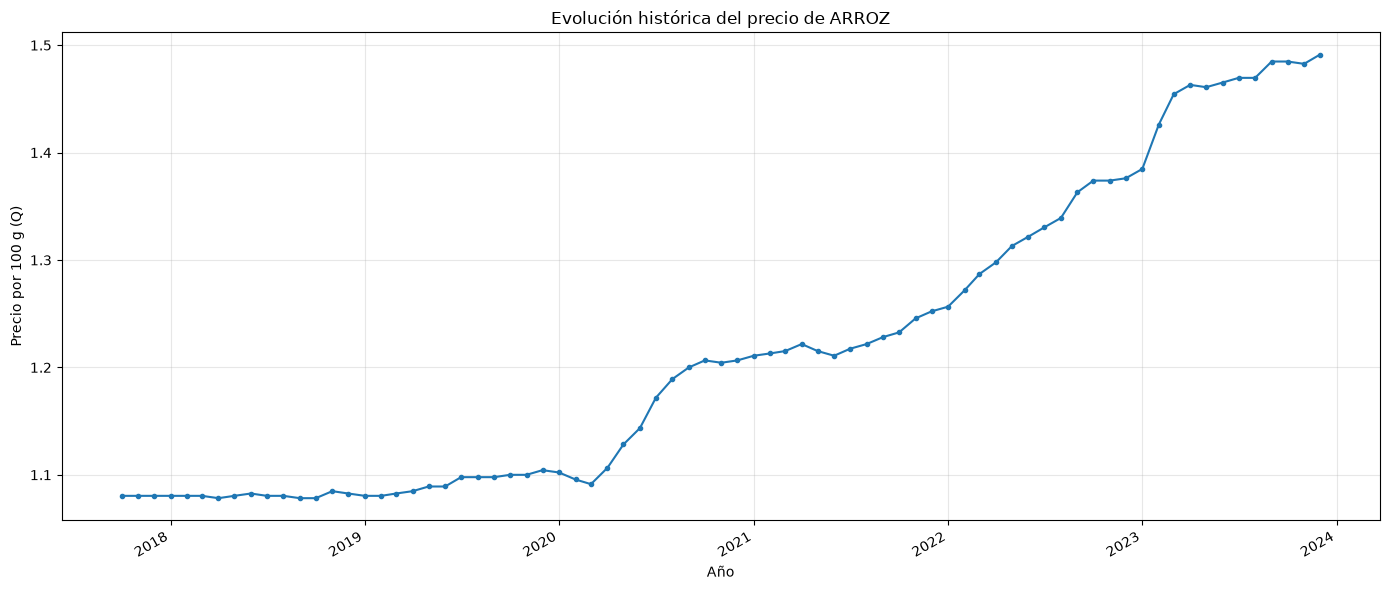

In [11]:
fig, ax = food.plot_timeline('general')

Tendencia general de crecimiento 

In [12]:
food_timeline_summary = food.price_summary("general")

labels = {
    "first": "Primer precio registrado",
    "latest": "Último precio registrado",
    "lowest": "Precio más bajo",
    "highest": "Precio más alto",
}

print(f"Resumen de {food.name} — región general")
print("=" * 50)

for key, label in labels.items():
    point = food_timeline_summary[key]

    if point is None:
        print(f"{label}: sin información")
        continue

    print(
        f"{label}: "
        f"Q{point.price_per_100g:.2f} por 100 g "
        f"({point.month:02d}/{point.year})"
    )

Resumen de ARROZ — región general
Primer precio registrado: Q1.08 por 100 g (10/2017)
Último precio registrado: Q1.49 por 100 g (12/2023)
Precio más bajo: Q1.08 por 100 g (04/2018)
Precio más alto: Q1.49 por 100 g (12/2023)


#### Arroz corriente - Explorarcion de datos

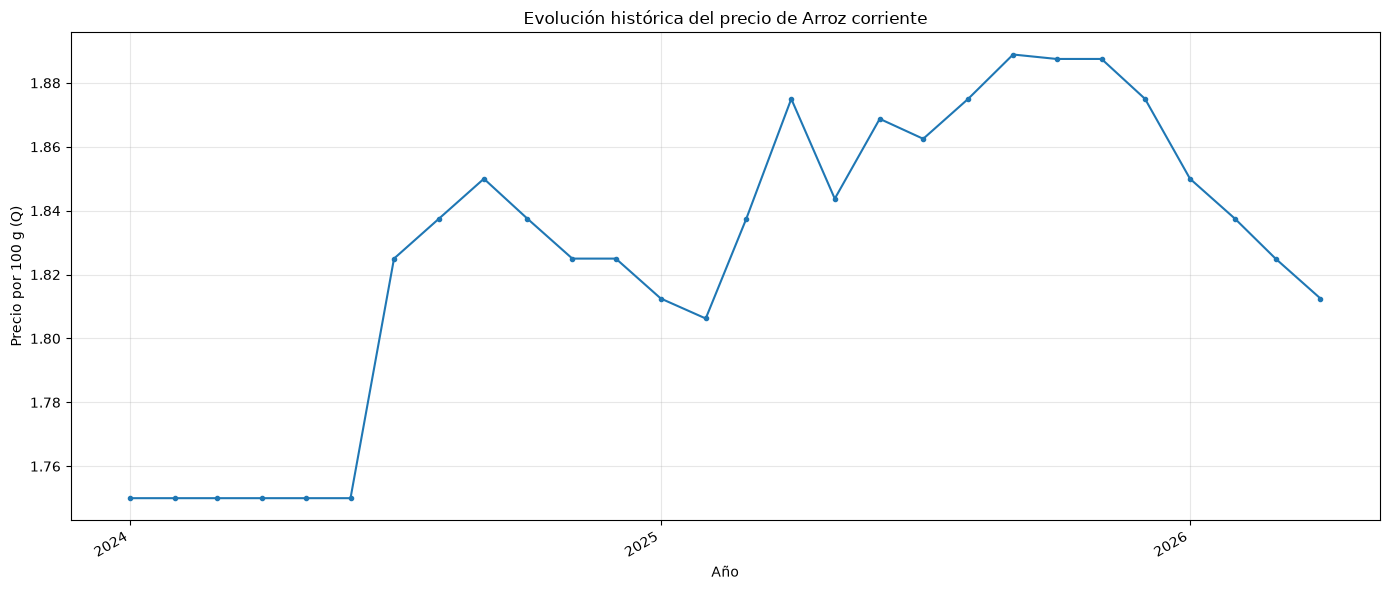

In [13]:
fig, ax = catalog.get('arroz_corriente').plot_timeline('urbana')

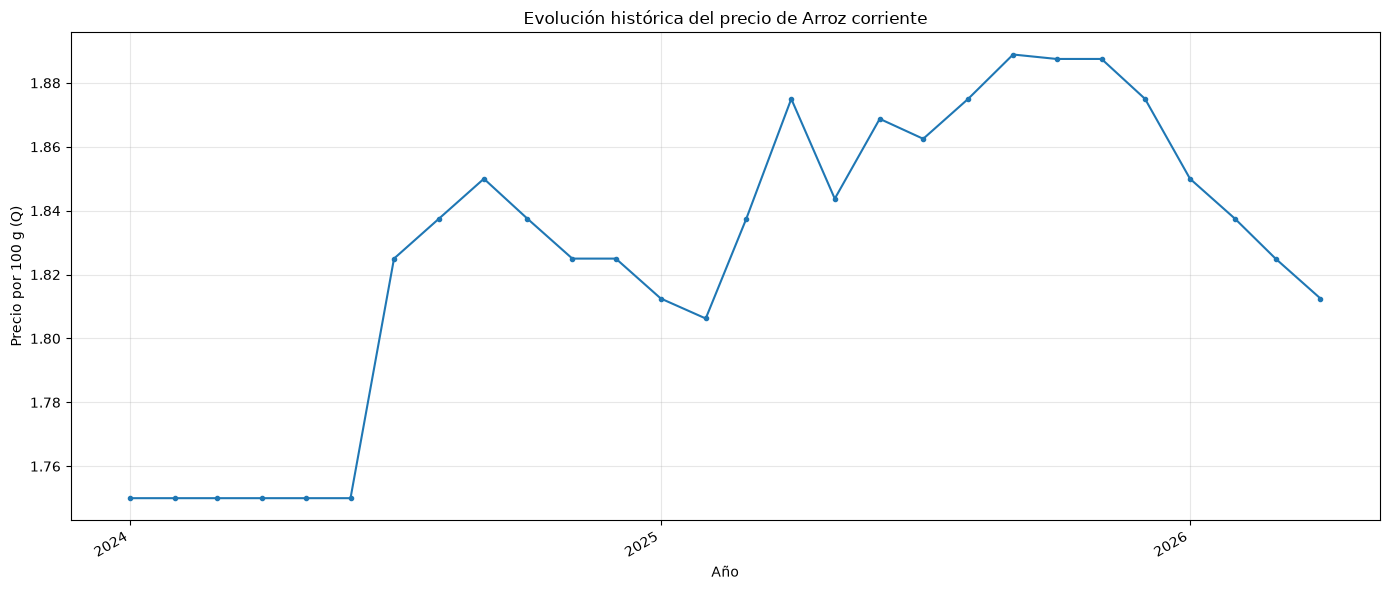

In [14]:
fig, ax = catalog.get('arroz_corriente').plot_timeline('rural')

Los precios se mantienen en ambas regiones asi que usamos la general para resumir la comparacion

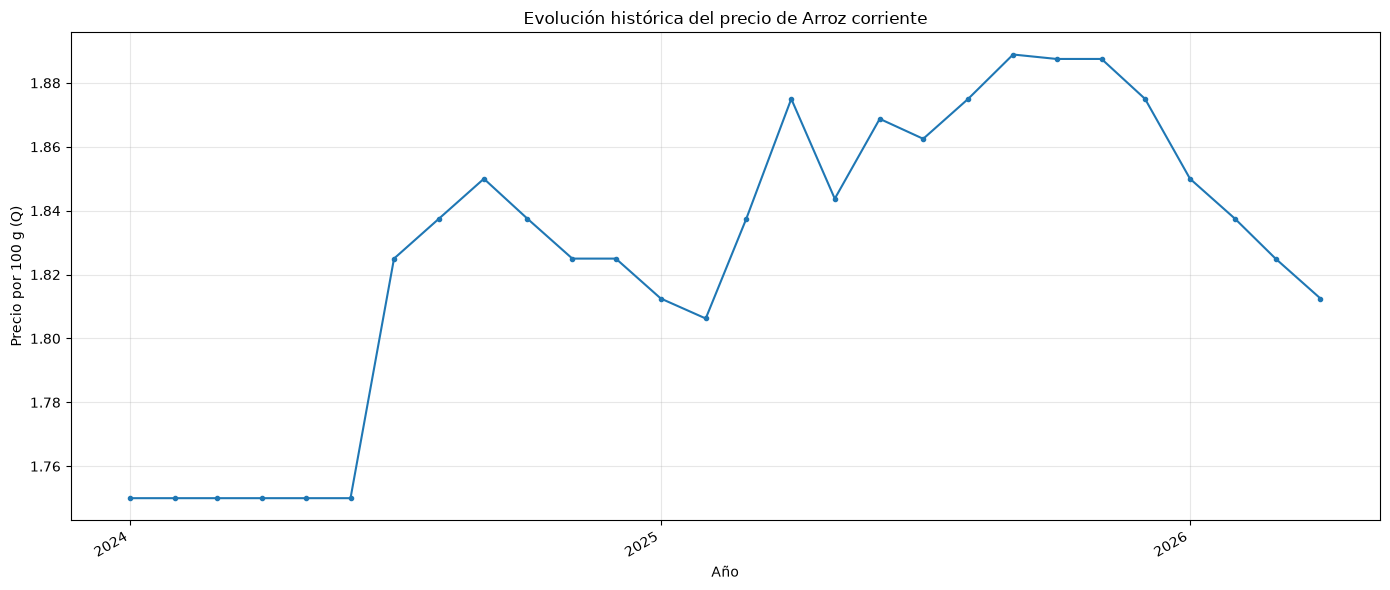

In [15]:
fig, ax = catalog.get('arroz_corriente').plot_timeline('general')

Si comparamos el primer punto del ultimo, podemos decir que si hubo un aumento en el precio, pero sin una tendencia clara, muy fluctante en el periodo. 

In [16]:
target_food = catalog.get('arroz_corriente')
food_timeline_summary = target_food.price_summary("general")

labels = {
    "first": "Primer precio registrado",
    "latest": "Último precio registrado",
    "lowest": "Precio más bajo",
    "highest": "Precio más alto",
}

print(f"Resumen de {target_food.name} — región general")
print("=" * 50)

for key, label in labels.items():
    point = food_timeline_summary[key]

    if point is None:
        print(f"{label}: sin información")
        continue

    print(
        f"{label}: "
        f"Q{point.price_per_100g:.2f} por 100 g "
        f"({point.month:02d}/{point.year})"
    )

Resumen de Arroz corriente — región general
Primer precio registrado: Q1.75 por 100 g (01/2024)
Último precio registrado: Q1.81 por 100 g (04/2026)
Precio más bajo: Q1.75 por 100 g (02/2024)
Precio más alto: Q1.89 por 100 g (09/2025)


#### Arroz Precocido - Explorarcion de datos

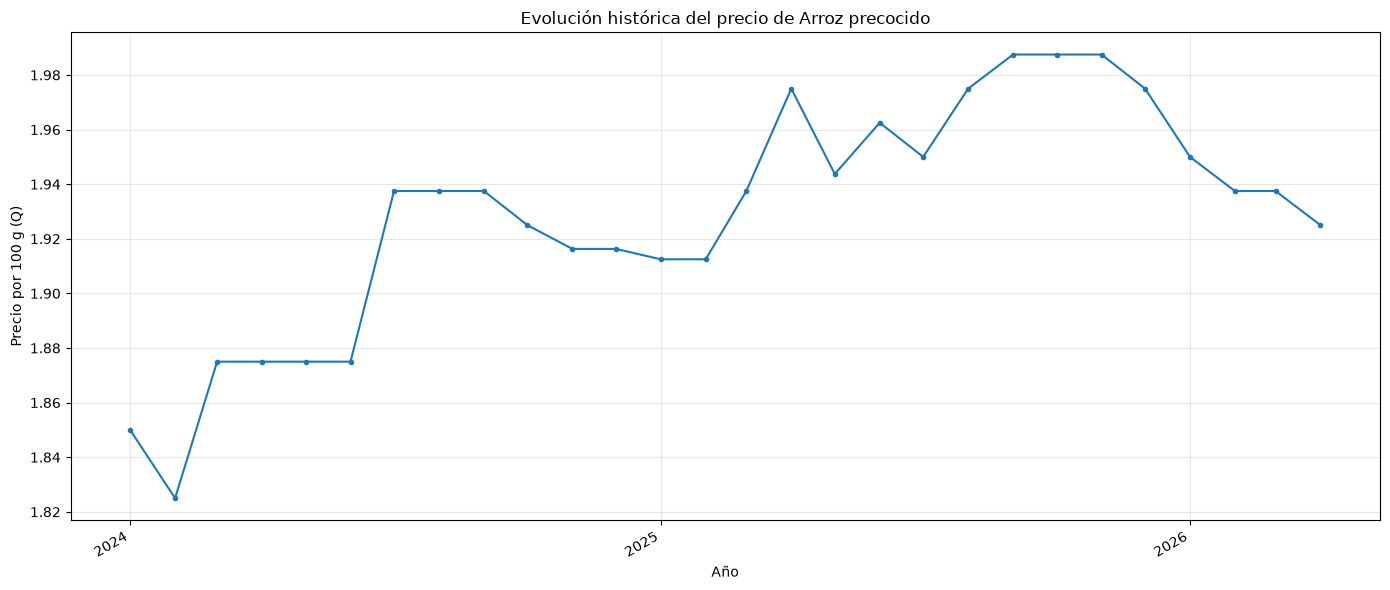

In [17]:
fig, ax = catalog.get('arroz_precocido').plot_timeline('urbana')

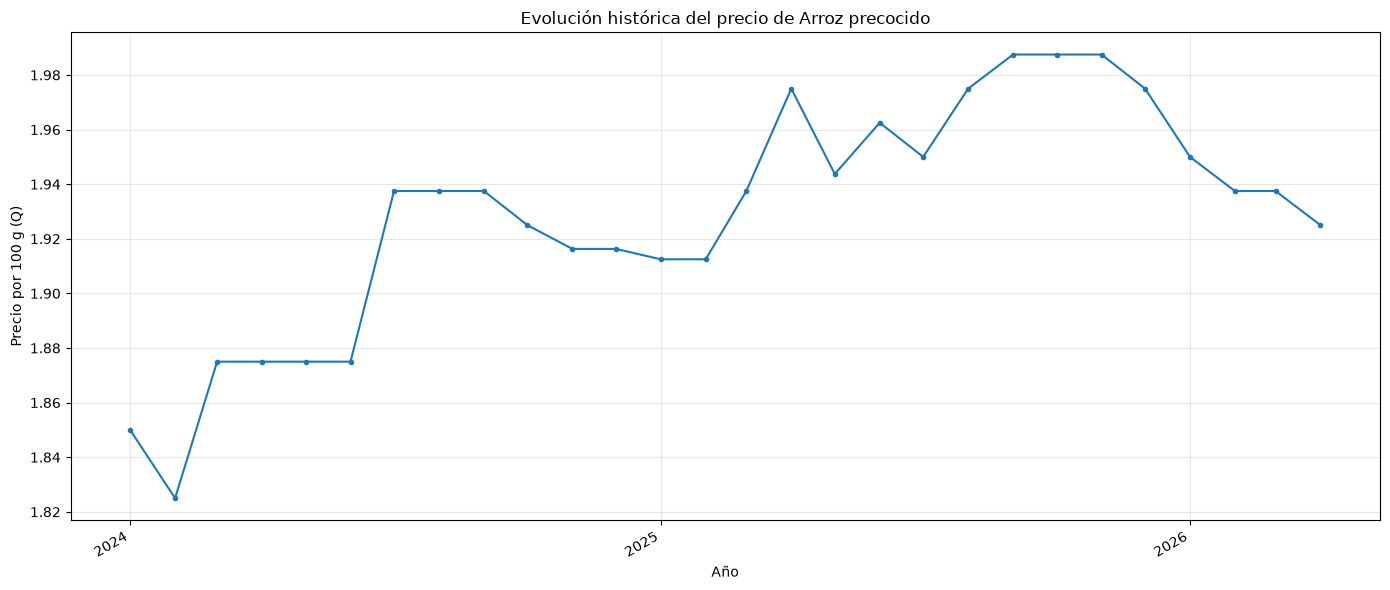

In [18]:
fig, ax = catalog.get('arroz_precocido').plot_timeline('rural')

Los precios se mantienen en ambas regiones asi que usamos la general para resumir la comparacion

Si comparamos el primer punto del ultimo, podemos decir que si hubo un aumento en el precio, pero sin una tendencia clara, muy fluctante en el periodo. 

In [19]:
target_food = catalog.get('arroz_precocido')
food_timeline_summary = target_food.price_summary("general")

labels = {
    "first": "Primer precio registrado",
    "latest": "Último precio registrado",
    "lowest": "Precio más bajo",
    "highest": "Precio más alto",
}

print(f"Resumen de {target_food.name} — región general")
print("=" * 50)

for key, label in labels.items():
    point = food_timeline_summary[key]

    if point is None:
        print(f"{label}: sin información")
        continue

    print(
        f"{label}: "
        f"Q{point.price_per_100g:.2f} por 100 g "
        f"({point.month:02d}/{point.year})"
    )

Resumen de Arroz precocido — región general
Primer precio registrado: Q1.85 por 100 g (01/2024)
Último precio registrado: Q1.92 por 100 g (04/2026)
Precio más bajo: Q1.82 por 100 g (02/2024)
Precio más alto: Q1.99 por 100 g (11/2025)


#### Conclusion

Dado que, en primer lugar el nombre `arroz corriente` sugiere ser lo mismo que `arroz`; en segunda lugar, en tanto al precio, tanto el precocido como el corriente, tienen una continuidad lógica, sin embargo precio inicial del corriente es mas cercano que el del precocido

Por estos motivos, se procede a mergear datos de cba `arroz corriente` y `arroz`. Y `arroz precocido` queda separado e independiente. 

In [20]:
#catalog.merge_foods('arroz', 'arroz_corriente')
# mergeado hasta el final para no afectar el iterable

## Avena de toda clase


In [21]:
food = next(catalog_iterable)
print(food.id)

avena_de_toda_clase


In [22]:
food =catalog.get('avena_de_toda_clase')
food.years_by_region()

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023],
 'rural': [],
 'urbana': []}

No tiene datos de 2024 a 2026

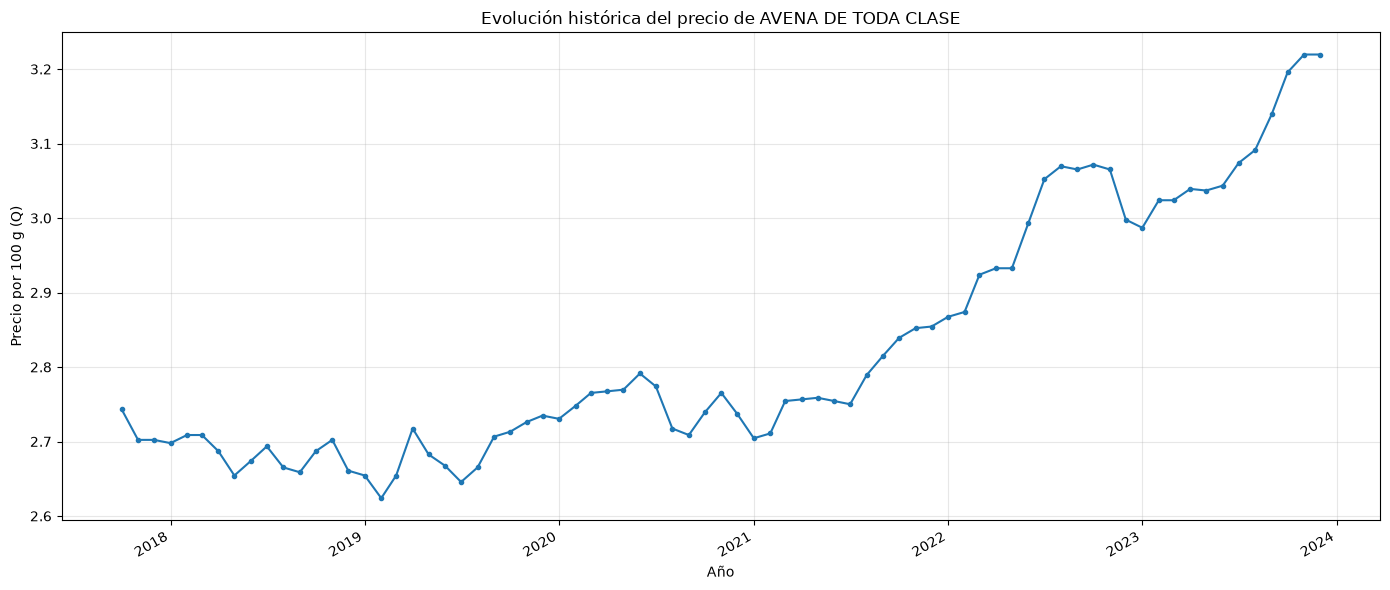

In [23]:
fig, ax = food.plot_timeline('general')

In [24]:
for food in catalog:
    if food.id.startswith('avena'):
        print(food)
        print("===============")
        for region, ptf in food.price_timelines.items(): 
            print(f"Region: {region}")
            print(ptf.avg_daily_grams())

Food(id='avena_de_toda_clase', name='AVENA DE TODA CLASE', category='CEREALES', aliases={'AVENA DE TODA CLASE', 'Avena de toda clase'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002927414F390>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Region: general
10.479385045422797
Food(id='avena_mosh', name='Avena/mosh', category=None, aliases={'Avena/mosh'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002927476A030>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Region: rural
2.4828176204512586


Por nombre, el candidato a mergear es Avena/Mosh. Aunque unicamente tenga presencia en el area rural 

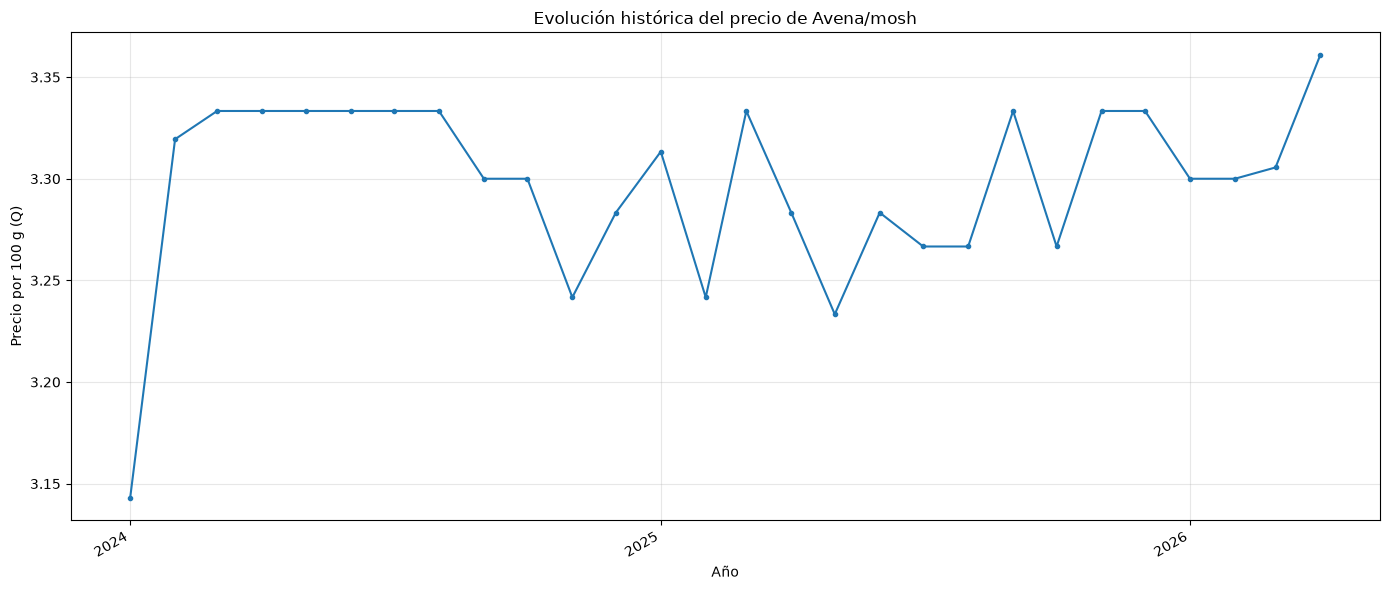

In [25]:
fig, ax = catalog.get('avena_mosh').plot_timeline('rural')

In [26]:
labels = {
    'first': 'Primer precio registrado',
    'latest': 'Último precio registrado',
    'lowest': 'Precio más bajo',
    'highest': 'Precio más alto',
}

for _food, region in [('avena_de_toda_clase', 'general'), ('avena_mosh', 'rural')]:
    target_food = catalog.get(_food)
    print(f'Resumen de {target_food.name} — región {region}')
    print('=' * 50)
    for key, label in labels.items():
        point = target_food.price_summary(region)[key]
        if point is None:
            print(f'{label}: sin información')
            continue
        print(f'{label}: Q{point.price_per_100g:.2f} por 100 g ({point.month:02d}/{point.year})')
    print()

Resumen de AVENA DE TODA CLASE — región general
Primer precio registrado: Q2.74 por 100 g (10/2017)
Último precio registrado: Q3.22 por 100 g (12/2023)
Precio más bajo: Q2.62 por 100 g (02/2019)
Precio más alto: Q3.22 por 100 g (11/2023)

Resumen de Avena/mosh — región rural
Primer precio registrado: Q3.14 por 100 g (01/2024)
Último precio registrado: Q3.36 por 100 g (04/2026)
Precio más bajo: Q3.14 por 100 g (01/2024)
Precio más alto: Q3.36 por 100 g (04/2026)



#### Conclusión

La similitud del nombre y la continuidad observada en los precios respaldan la unificación de `Avena/mosh` con `Avena de toda clase`. 

## Pan Frances

In [27]:
food = next(catalog_iterable)
print(food.id)

pan_frances


In [28]:
food = catalog.get('pan_frances')

In [29]:
print(food.id)
print(food.years_by_region())

pan_frances
{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


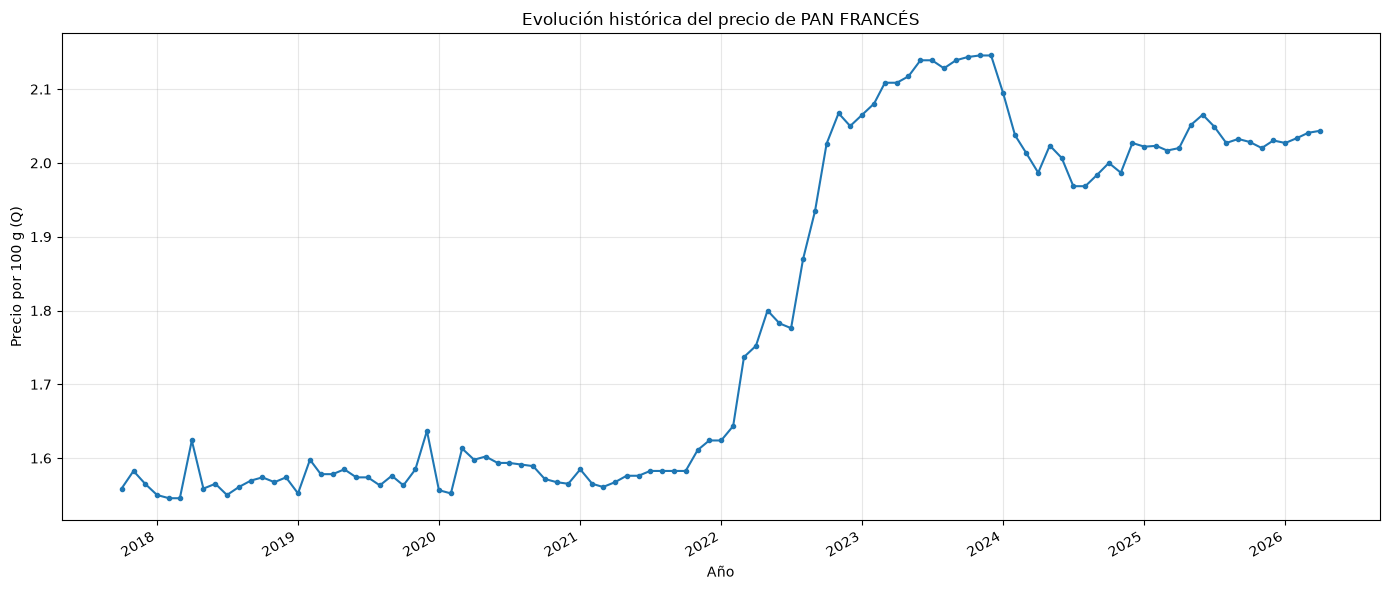

In [30]:
fig, ax = food.plot_timeline('general')

No es requerida ninguna accion adicional 

## Pan Dulce

In [31]:
food = next(catalog_iterable)
print(food.id)

pan_dulce


In [32]:
food = catalog.get('pan_dulce')
print()

pan_dulce
{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


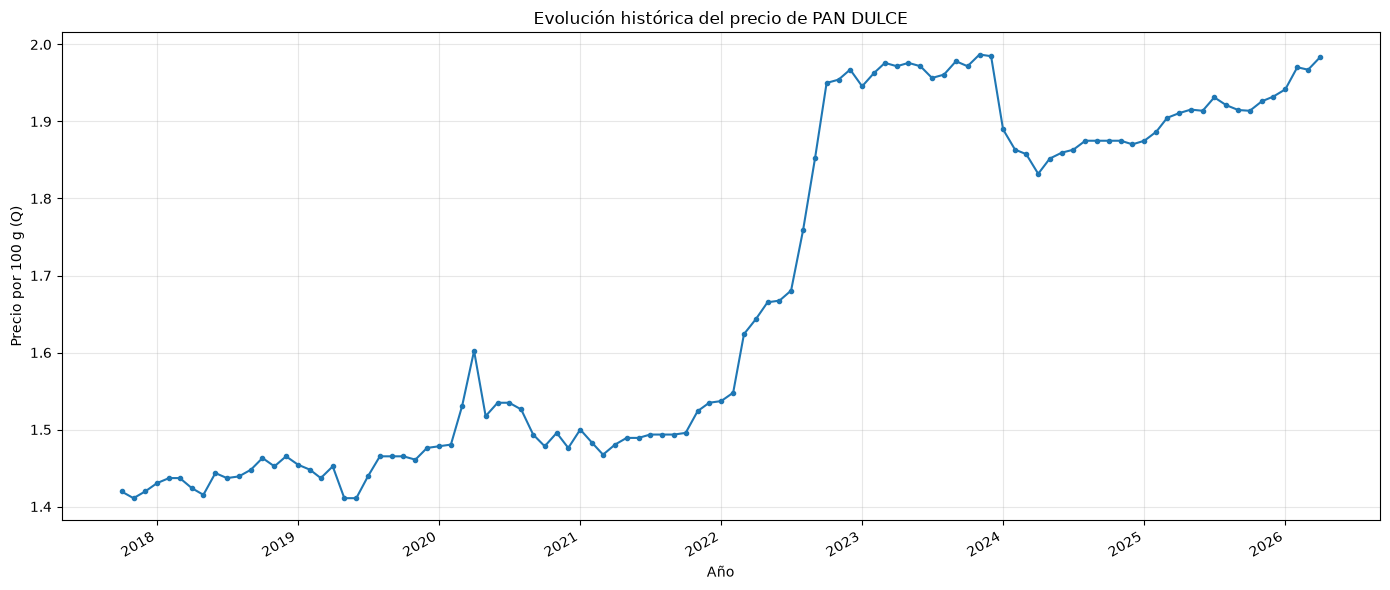

In [33]:
print(food.id)
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

No es requerida ninguna accion adicional 

## Fideos

In [34]:
food = catalog.get('fideos')
print(food.id)

fideos


{'general': [2017, 2018, 2019, 2020], 'rural': [], 'urbana': []}


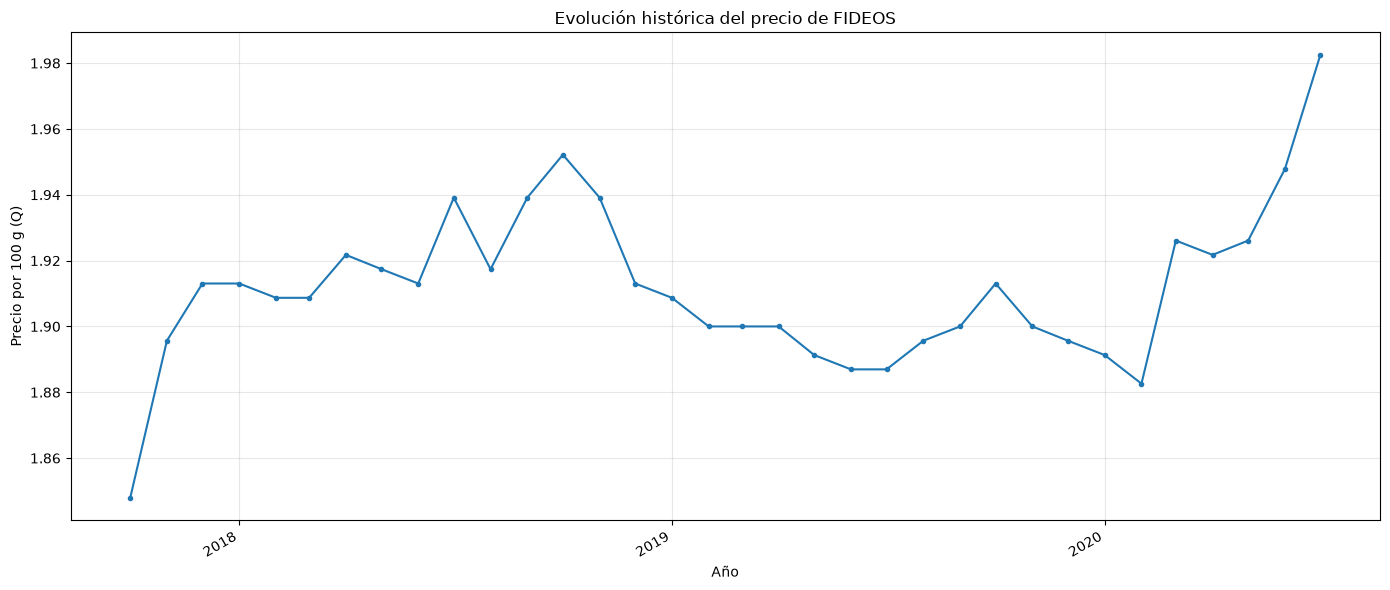

In [35]:
food = catalog.get('fideos')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [36]:
labels = {
    'first': 'Primer precio registrado',
    'latest': 'Último precio registrado',
    'lowest': 'Precio más bajo',
    'highest': 'Precio más alto',
}
region = 'general'
print(f'Resumen de {food.name} — región {region}')
print('=' * 50)
for key, label in labels.items():
    point = food.price_summary(region)[key]
    if point is None:
        print(f'{label}: sin información')
        continue
    print(f'{label}: Q{point.price_per_100g:.2f} por 100 g ({point.month:02d}/{point.year})')
print()

Resumen de FIDEOS — región general
Primer precio registrado: Q1.85 por 100 g (10/2017)
Último precio registrado: Q1.98 por 100 g (07/2020)
Precio más bajo: Q1.85 por 100 g (10/2017)
Precio más alto: Q1.98 por 100 g (07/2020)



La serie original de `FIDEOS` termina en julio de 2020. Es necesario buscar candidatos que permitan completar el periodo posterior.

In [37]:
candidates = [
    catalog.get('fideos_en_todas_sus_formas_excepto_macarrones_y_espagueti'),
]

for candidate in candidates:
    print(candidate.name)
    print(candidate.years_by_region())
    for region, timeline in candidate.price_timelines.items():
        print(f'Consumo diario promedio ({region}): {timeline.avg_daily_grams():.2f} g')
    print()

labels = {
    'first': 'Primer precio registrado',
    'latest': 'Último precio registrado',
    'lowest': 'Precio más bajo',
    'highest': 'Precio más alto',
}


Fideos en todas sus formas (Excepto macarrones y espagueti)
{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}
Consumo diario promedio (rural): 6.63 g
Consumo diario promedio (urbana): 5.86 g
Consumo diario promedio (general): 6.24 g



Resumen de Fideos en todas sus formas (Excepto macarrones y espagueti) — región rural
Primer precio registrado: Q2.25 por 100 g (01/2024)
Último precio registrado: Q2.10 por 100 g (04/2026)
Precio más bajo: Q2.09 por 100 g (02/2024)
Precio más alto: Q2.25 por 100 g (01/2024)

Resumen de Fideos en todas sus formas (Excepto macarrones y espagueti) — región urbana
Primer precio registrado: Q2.25 por 100 g (01/2024)
Último precio registrado: Q2.10 por 100 g (04/2026)
Precio más bajo: Q2.09 por 100 g (02/2024)
Precio más alto: Q2.25 por 100 g (01/2024)

Resumen de Fideos en todas sus formas (Excepto macarrones y espagueti) — región general
Primer precio registrado: Q2.25 por 100 g (01/2024)
Último precio registrado: Q2.10 por 100 g (04/2026)
Precio más bajo: Q2.09 por 100 g (02/2024)
Precio más alto: Q2.25 por 100 g (01/2024)



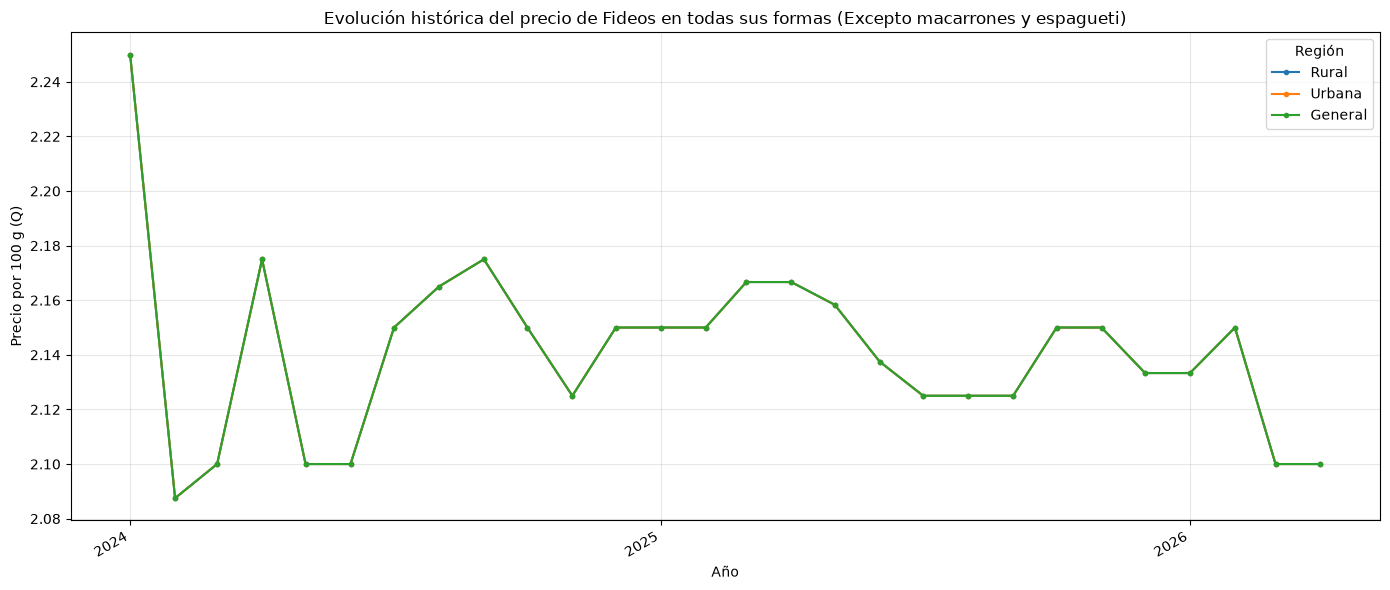

In [38]:
for _food in candidates:
    fig, ax = _food.plot_timeline()
    for _region in ('rural', 'urbana', 'general'):
        print(f'Resumen de {_food.name} — región {_region}')
        print('=' * 50)
        for key, label in labels.items():
            point = _food.price_summary(_region)[key]
            if point is None:
                print(f'{label}: sin información')
                continue
            print(f'{label}: Q{point.price_per_100g:.2f} por 100 g ({point.month:02d}/{point.year})')
        print()

`Fideos en todas sus formas (excepto macarrones y espagueti)` cubre desde enero de 2024. Su primer precio general es Q2.25 por 100 g, cercano al último precio de 2023, pero todavía debemos cubrir agosto de 2020 a diciembre de 2023.

PASTAS ALIMENTICIAS
{'general': [2020], 'rural': [], 'urbana': []}
Resumen de PASTAS ALIMENTICIAS — región rural
Primer precio registrado: sin información
Último precio registrado: sin información
Precio más bajo: sin información
Precio más alto: sin información

Resumen de PASTAS ALIMENTICIAS — región urbana
Primer precio registrado: sin información
Último precio registrado: sin información
Precio más bajo: sin información
Precio más alto: sin información

Resumen de PASTAS ALIMENTICIAS — región general
Primer precio registrado: Q2.00 por 100 g (08/2020)
Último precio registrado: Q2.00 por 100 g (08/2020)
Precio más bajo: Q2.00 por 100 g (08/2020)
Precio más alto: Q2.00 por 100 g (08/2020)

PASTAS DE TODOS LOS TIPOS
{'general': [2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}
Resumen de PASTAS DE TODOS LOS TIPOS — región rural
Primer precio registrado: sin información
Último precio registrado: sin información
Precio más bajo: sin información
Precio más alto: sin información

Resum

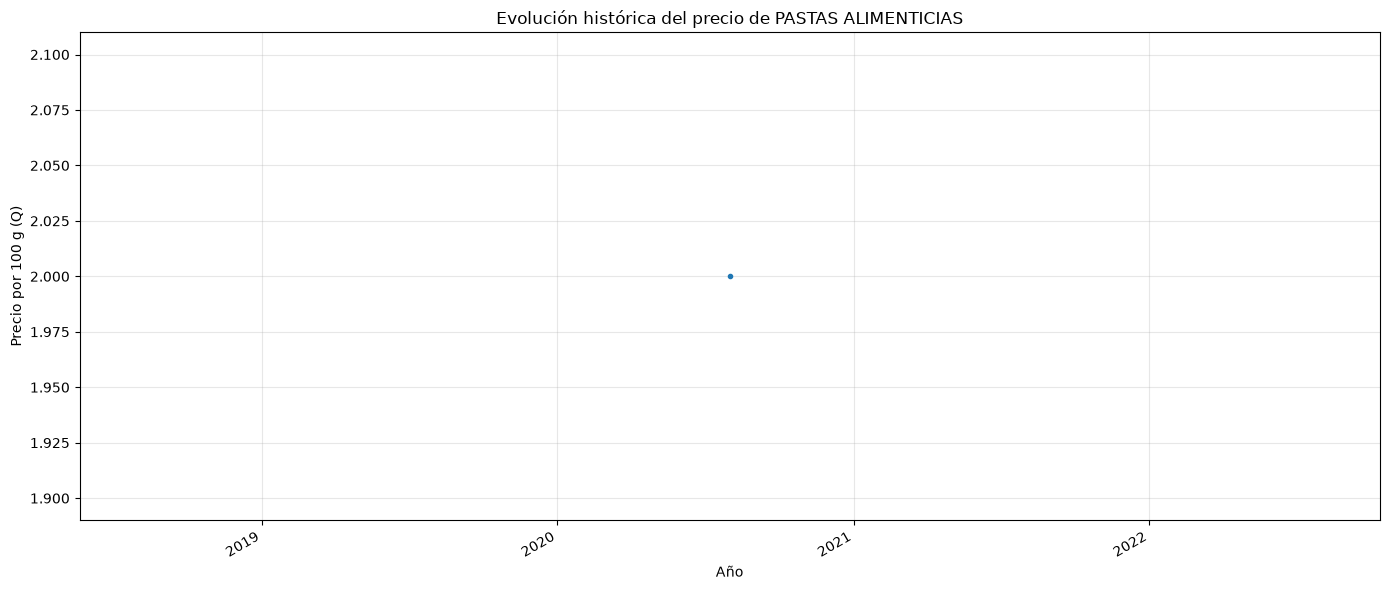

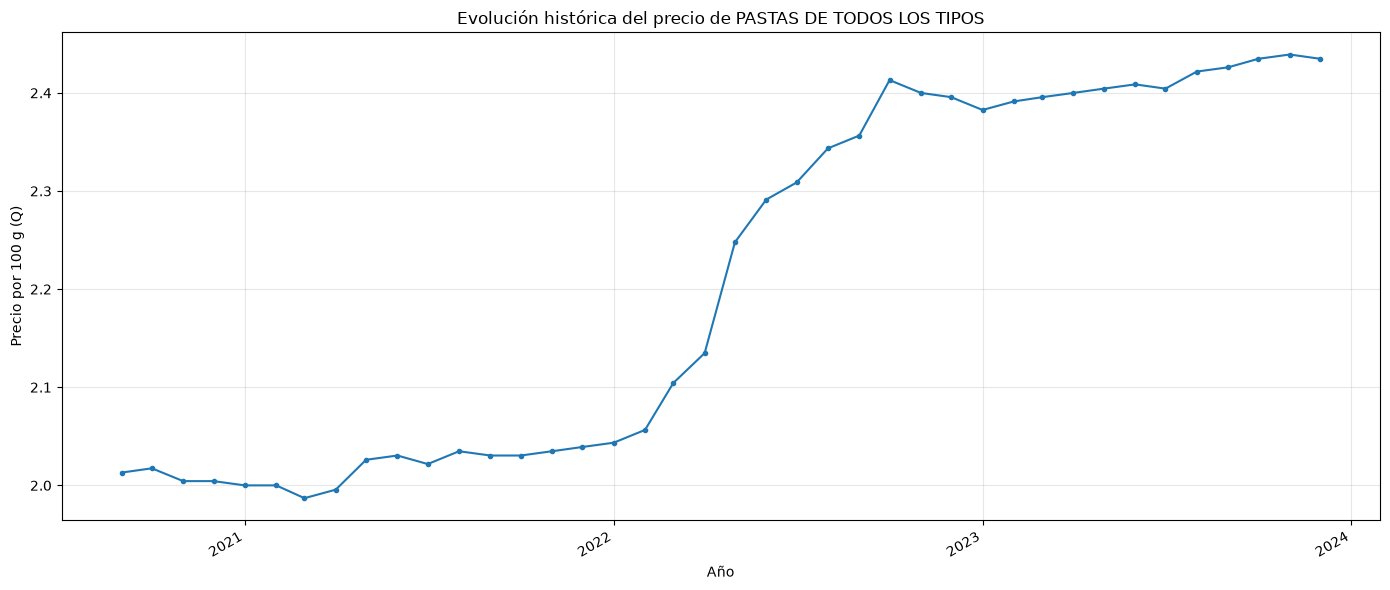

In [39]:
other_candidates = [
    catalog.get('pastas_alimenticias'),
    catalog.get('pastas_de_todos_los_tipos'),
]
for _food in other_candidates:
    print(_food.name)
    print(_food.years_by_region())
    fig, ax = _food.plot_timeline('general')
    for _region in ('rural', 'urbana', 'general'):
        print(f'Resumen de {_food.name} — región {_region}')
        print('=' * 50)
        for key, label in labels.items():
            point = _food.price_summary(_region)[key]
            if point is None:
                print(f'{label}: sin información')
                continue
            print(f'{label}: Q{point.price_per_100g:.2f} por 100 g ({point.month:02d}/{point.year})')
        print()

candidates += other_candidates

#### Conclusión

Los candidatos forman una serie temporal continua y sus precios de enlace son coherentes: `FIDEOS` termina en julio de 2020 con Q1.98 por 100 g; `PASTAS ALIMENTICIAS` aporta agosto de 2020 con Q2.00; `PASTAS DE TODOS LOS TIPOS` comienza en septiembre de 2020 con Q2.01 y llega a diciembre de 2023 con Q2.43; finalmente, `Fideos en todas sus formas (excepto macarrones y espagueti)` comienza en enero de 2024 con Q2.25.

Por nombre, cobertura temporal y continuidad de precios, se unifican los tres candidatos con `FIDEOS`. Los macarrones y el espagueti quedan excluidos porque el propio nombre del candidato regional los distingue.

In [40]:
#catalog.merge_foods('arroz', 'arroz_corriente')
#catalog.merge_foods('avena_de_toda_clase', 'avena_mosh')
#catalog.merge_foods('fideos', 'pastas_alimenticias')
#catalog.merge_foods('fideos', 'pastas_de_todos_los_tipos')
#catalog.merge_foods('fideos', 'fideos_en_todas_sus_formas_excepto_macarrones_y_espagueti')

# 3. Merge con INCAP

In [41]:
incap_report = enrich_catalog_with_incap(
    catalog,
    PROJECT_ROOT / 'data' / 'raw' / 'incap' / 'tabladecomposiciondealimentos.pdf',
)
incap_report

Loaded data from cache serialized data


{'matched': 27, 'unmatched': 75}

In [42]:
matched_foods = [food for food in catalog if food.nutrition is not None]
[(food.name, food.nutrition.incap_name, food.nutrition_match_score) for food in matched_foods[:10]]

[('ARROZ', 'CREMA DE ARROZ, HARINA', 0.5925),
 ('PAN FRANCÉS', 'PAN FRANCES DE COCO', 0.7596),
 ('PAN DULCE', 'PAN DULCE, DE COCO', 0.744),
 ('FIDEOS', 'FIDEOS PARA CHOW MEIN', 0.638),
 ('CARNE DE POLLO O GALLINA', 'CALDO DE POLLO, O GALLINA', 0.5788),
 ('EMBUTIDOS', 'PIZZA HUT, DE EMBUTIDOS, CONCHA GRUESA', 0.59),
 ('LECHE EN POLVO',
  'BEBIDA, ALTO CONT.PROTEÍNA (78%), BASE SUERO DE LECHE, POLVO',
  0.5608),
 ('SANDIAS', 'SANDIA', 0.7706),
 ('TOMATE', 'MILTOMATE', 0.7),
 ('GÜISQUIL', 'CHAYOTE/GUISQUIL/PATASTE, CRUDO', 0.5883)]